# DeepSeek hidden-risk annual discovery eval

Este notebook ejecuta la eval anual genérica de riesgos implícitos. Cada caso contiene un único `Item 1A. Risk Factors` de un año fiscal y el modelo debe identificar riesgos subyacentes o infraenfatizados con evidencia textual del mismo año.

La eval ya no depende de categorías específicas de Guidewire: el modelo elige un `sector_specific_topic`, pero debe mapear cada hallazgo a un `risk_domain` universal para poder comparar bancos, software, aseguradoras u otras compañías con el mismo flujo.

## Qué se comprueba

- El fixture `hidden_risk_annual.discovery.json` puede contener casos de cualquier compañía o sector.
- Cada caso se evalúa de forma anual e independiente: no se pasa el año anterior al modelo.
- El modelo genera `sector_specific_topic` libremente, guiado por una taxonomía genérica de `risk_domain`.
- Si no hay gold set manual, el scorer usa discovery mode: valida evidencia textual y penaliza claims sin citas soportadas.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from types import SimpleNamespace

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'eval.json').exists():
            return candidate
    raise RuntimeError('Could not locate project root')


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIXTURE_PATH = PROJECT_ROOT / 'hidden_risk_annual.discovery.json'
OUTPUT_DIR = PROJECT_ROOT / 'eval_runs' / 'hidden_risk_annual_discovery'
FORCE_NEW_RUN = False
pd.set_option('display.max_colwidth', 220)


def project_relative(path: Path | str) -> str:
    candidate = Path(path)
    try:
        return str(candidate.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(candidate)


pd.DataFrame(
    [
        {
            'fixture': project_relative(FIXTURE_PATH),
            'output_dir': project_relative(OUTPUT_DIR),
            'force_new_run': FORCE_NEW_RUN,
        }
    ]
)


,fixture,output_dir,force_new_run
0,hidden_risk_annual.discovery.json,eval_runs/hidden_risk_annual_discovery,False


## Cargar y validar el fixture

El fixture es autocontenido: cada caso trae el texto anual completo que se manda al modelo. Las citas aceptadas de los candidatos se comprueban contra ese texto para detectar etiquetas mal ancladas.

In [2]:
from src.evals.hidden_risk_annual import (
    DEFAULT_MATCH_THRESHOLD,
    DEFAULT_MAX_UNSUPPORTED_CLAIM_RATE,
    DEFAULT_MIN_PRECISION,
    DEFAULT_MIN_RECALL,
    expected_model_metadata,
    load_hidden_risk_eval,
    quote_is_supported,
    run_hidden_risk_annual_eval,
    score_hidden_risk_annual,
    score_to_dict,
)
from src.llm.deepseek import DeepSeekAPIError, DeepSeekClient
from src.prompts.hidden_risk_annual import build_hidden_risk_annual_messages

fixture = load_hidden_risk_eval(FIXTURE_PATH)
rows = []
expected_rows = []
for case in fixture['cases']:
    text = case['input']['text']
    expected = case.get('expected_hidden_risks', [])
    unsupported_expected_quotes = []
    for risk in expected:
        supported = [quote for quote in risk.get('accepted_evidence_quotes', []) if quote_is_supported(quote, text)]
        if risk.get('accepted_evidence_quotes') and not supported:
            unsupported_expected_quotes.append(risk['risk_id'])
        expected_rows.append(
            {
                'company': case['company'],
                'ticker': case['ticker'],
                'year': case['year'],
                'risk_id': risk['risk_id'],
                'risk_domain': risk.get('risk_domain') or risk.get('theme'),
                'sector_specific_topic': risk.get('sector_specific_topic'),
                'hiddenness_type': risk.get('hiddenness_type'),
                'implicit_risk': risk['implicit_risk'],
                'review_status': risk.get('review_status', 'candidate'),
                'evidence_terms': ', '.join(risk.get('required_evidence_terms', [])),
            }
        )
    rows.append(
        {
            'case_id': case['id'],
            'company': case['company'],
            'ticker': case['ticker'],
            'sector': case.get('sector'),
            'industry': case.get('industry'),
            'year': case['year'],
            'words': case['risk_factor_used']['word_count'],
            'expected_hidden_risks': len(expected),
            'scoring_mode': 'benchmark' if expected else 'discovery',
            'unsupported_expected_quotes': ', '.join(unsupported_expected_quotes),
        }
    )

case_df = pd.DataFrame(rows)
expected_df = pd.DataFrame(expected_rows)
case_df

,case_id,company,ticker,sector,industry,year,words,expected_hidden_risks,scoring_mode,unsupported_expected_quotes
0,gwre-2021-10k-item-1a-hidden-risk-discovery,"Guidewire Software, Inc.",GWRE,software,insurance software,2021,20624,0,discovery,
1,gwre-2022-10k-item-1a-hidden-risk-discovery,"Guidewire Software, Inc.",GWRE,software,insurance software,2022,20772,0,discovery,
2,gwre-2023-10k-item-1a-hidden-risk-discovery,"Guidewire Software, Inc.",GWRE,software,insurance software,2023,22152,0,discovery,
3,gwre-2024-10k-item-1a-hidden-risk-discovery,"Guidewire Software, Inc.",GWRE,software,insurance software,2024,23042,0,discovery,
4,gwre-2025-10k-item-1a-hidden-risk-discovery,"Guidewire Software, Inc.",GWRE,software,insurance software,2025,23813,0,discovery,


In [3]:
if expected_df.empty:
    display(Markdown('No hay `expected_hidden_risks` en este fixture: se ejecutará en **discovery mode** y se puntuará por soporte de evidencia.'))
else:
    display(expected_df[['company', 'year', 'risk_id', 'risk_domain', 'sector_specific_topic', 'hiddenness_type', 'implicit_risk', 'review_status']])

No hay `expected_hidden_risks` en este fixture: se ejecutará en **discovery mode** y se puntuará por soporte de evidencia.

## Prompt anual

El prompt recibe solo el año actual. Pide una lista corta de riesgos implícitos con citas exactas y permite devolver `hidden_risks: []` si no hay señal suficiente.

In [4]:
sample_case = fixture['cases'][-1]
sample_messages = build_hidden_risk_annual_messages(sample_case, sample_case['input']['text'])
prompt_preview = pd.DataFrame(
    [
        {
            'role': message['role'],
            'characters': len(message['content']),
            'preview': message['content'][:500].replace('\n', ' '),
        }
        for message in sample_messages
    ]
)
prompt_preview

,role,characters,preview
0,system,2861,You are evaluating implicit or underemphasized risks inside one SEC 10-K Item 1A Risk Factors section. Return strict JSON only. The user will provide the Item 1A section text for one company and year. Your job is no...
1,user,159487,"Analyze this single-year 10-K Item 1A section for implicit or underemphasized risks and return them as strict JSON. Company: Guidewire Software, Inc. Ticker: GWRE Year: 2025 Section: Item 1A. Risk Factors Sector met..."


## Ejecutar DeepSeek

La ejecución guarda resultados por caso y un `summary.json` bajo `eval_runs/hidden_risk_annual_discovery/<run_id>/`. Si falta `.env` o la API falla, el notebook conserva la validación del fixture y deja el error visible sin romper la ejecución completa.

In [5]:
run_summary = None
run_error = None
progress_messages = []
summary_payload = None

existing_summaries = sorted(OUTPUT_DIR.glob('*/summary.json')) if OUTPUT_DIR.exists() else []
latest_summary_path = existing_summaries[-1] if existing_summaries and not FORCE_NEW_RUN else None

if latest_summary_path is not None:
    summary_payload = json.loads(latest_summary_path.read_text(encoding='utf-8'))
    run_summary = SimpleNamespace(
        run_id=summary_payload['run_id'],
        output_dir=latest_summary_path.parent,
    )
    display(Markdown(f"**Run existente reutilizado:** `{run_summary.run_id}` en `{project_relative(run_summary.output_dir)}`"))
else:
    try:
        client = DeepSeekClient.from_env(PROJECT_ROOT / '.env')
        run_summary = run_hidden_risk_annual_eval(
            client,
            eval_path=FIXTURE_PATH,
            output_dir=OUTPUT_DIR,
            min_recall=DEFAULT_MIN_RECALL,
            min_precision=DEFAULT_MIN_PRECISION,
            max_unsupported_claim_rate=DEFAULT_MAX_UNSUPPORTED_CLAIM_RATE,
            match_threshold=DEFAULT_MATCH_THRESHOLD,
            progress_callback=progress_messages.append,
        )
        summary_path = run_summary.output_dir / 'summary.json'
        summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
    except (DeepSeekAPIError, OSError, RuntimeError, ValueError) as exc:
        run_error = exc

if run_summary is None:
    display(Markdown(f"**No se pudo ejecutar DeepSeek en esta ejecución.** `{type(run_error).__name__}: {run_error}`"))
elif latest_summary_path is None:
    display(Markdown(f"**Run completado:** `{run_summary.run_id}` en `{project_relative(run_summary.output_dir)}`"))

pd.DataFrame({'progress': progress_messages})


**Run existente reutilizado:** `20260629T191956Z` en `eval_runs/hidden_risk_annual_discovery/20260629T191956Z`

,progress


## Resultados y scoring

El scorer compara tema, similitud básica del riesgo implícito y términos de evidencia. También separa los claims sin citas soportadas por el texto anual.

In [6]:
summary_df = pd.DataFrame()
model_risks_df = pd.DataFrame()
case_results = []

if run_summary is not None:
    if summary_payload is None:
        summary_path = run_summary.output_dir / 'summary.json'
        summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))

    cases_by_id = {case['id']: case for case in fixture['cases']}
    refreshed_results = []
    hidden_score_fields = {'missing', 'unexpected', 'unsupported_claims', 'matches', 'schema_errors'}

    for result in summary_payload['results']:
        case_result_path = Path(result['case_result_path'])
        if not case_result_path.exists():
            case_result_path = run_summary.output_dir / f"{result['case_id']}.json"
        case_result = json.loads(case_result_path.read_text(encoding='utf-8'))
        eval_case = cases_by_id.get(result['case_id'])
        if eval_case is not None:
            fresh_score = score_to_dict(
                score_hidden_risk_annual(
                    expected=eval_case.get('expected_hidden_risks') or [],
                    actual=case_result.get('model_output') or {},
                    case_text=eval_case['input']['text'],
                    expected_metadata=expected_model_metadata(eval_case),
                    min_recall=DEFAULT_MIN_RECALL,
                    min_precision=DEFAULT_MIN_PRECISION,
                    max_unsupported_claim_rate=DEFAULT_MAX_UNSUPPORTED_CLAIM_RATE,
                    match_threshold=DEFAULT_MATCH_THRESHOLD,
                )
            )
        else:
            fresh_score = case_result['score']

        case_result = {**case_result, 'score': fresh_score}
        case_results.append(case_result)
        refreshed_results.append(
            {
                **result,
                'case_result_path': project_relative(case_result_path),
                'score': fresh_score,
            }
        )

    summary_payload = {**summary_payload, 'results': refreshed_results}
    summary_df = pd.DataFrame(
        [
            {
                'year': result['year'],
                'case_id': result['case_id'],
                **{k: v for k, v in result['score'].items() if k not in hidden_score_fields},
                'total_tokens': (result.get('usage') or {}).get('total_tokens'),
            }
            for result in refreshed_results
        ]
    )

    risk_rows = []
    for result, case_result in zip(refreshed_results, case_results):
        score = case_result['score']
        matched_ids = {match.get('predicted_risk_id') for match in score.get('matches', [])}
        unsupported_ids = {risk.get('risk_id') for risk in score.get('unsupported_claims', [])}
        unexpected_ids = {risk.get('risk_id') for risk in score.get('unexpected', [])}
        schema_error_ids = {error.get('risk_id') for error in score.get('schema_errors', [])}
        scoring_mode = score.get('scoring_mode', 'discovery')
        for risk in (case_result.get('model_output') or {}).get('hidden_risks', []):
            evidence = risk.get('evidence') or []
            risk_id = risk.get('risk_id')
            if risk_id in schema_error_ids:
                match_status = 'schema_invalid'
            elif risk_id in matched_ids:
                match_status = 'matched_expected_candidate'
            elif risk_id in unsupported_ids:
                match_status = 'unsupported_evidence'
            elif scoring_mode == 'discovery':
                match_status = 'discovered_supported'
            elif risk_id in unexpected_ids:
                match_status = 'new_model_finding'
            else:
                match_status = 'unmatched'
            risk_rows.append(
                {
                    'year': result['year'],
                    'risk_id': risk_id,
                    'risk_domain': risk.get('risk_domain') or risk.get('theme'),
                    'sector_specific_topic': risk.get('sector_specific_topic') or risk.get('sector_specific_theme'),
                    'hiddenness_type': risk.get('hiddenness_type'),
                    'severity': risk.get('severity'),
                    'confidence': risk.get('confidence'),
                    'match_status': match_status,
                    'implicit_risk': risk.get('implicit_risk'),
                    'why_hidden_or_underemphasized': risk.get('why_hidden_or_underemphasized'),
                    'evidence_count': len(evidence),
                    'evidence_quotes': '\n\n'.join(
                        f"{index}. {item.get('quote', '')}\nReason: {item.get('reason', '')}"
                        for index, item in enumerate(evidence, start=1)
                    ),
                }
            )
    model_risks_df = pd.DataFrame(risk_rows)

summary_df


,year,case_id,scoring_mode,expected_count,predicted_count,matched_count,supported_predicted_count,unsupported_claim_count,schema_error_count,risk_recall,risk_precision,evidence_support_rate,unsupported_claim_rate,schema_valid_rate,passed,total_tokens
0,2021,gwre-2021-10k-item-1a-hidden-risk-discovery,discovery,0,3,0,3,0,0,1.0,1.0,1.0,0.0,1.0,True,28075
1,2022,gwre-2022-10k-item-1a-hidden-risk-discovery,discovery,0,3,0,3,0,0,1.0,1.0,1.0,0.0,1.0,True,30124
2,2023,gwre-2023-10k-item-1a-hidden-risk-discovery,discovery,0,3,0,3,0,0,1.0,1.0,1.0,0.0,1.0,True,32125
3,2024,gwre-2024-10k-item-1a-hidden-risk-discovery,discovery,0,4,0,4,0,0,1.0,1.0,1.0,0.0,1.0,True,33852
4,2025,gwre-2025-10k-item-1a-hidden-risk-discovery,discovery,0,3,0,3,0,0,1.0,1.0,1.0,0.0,1.0,True,32285


In [7]:
review_table = model_risks_df[
    [
        'year',
        'risk_domain',
        'sector_specific_topic',
        'hiddenness_type',
        'severity',
        'confidence',
        'match_status',
        'implicit_risk',
        'why_hidden_or_underemphasized',
    ]
] if not model_risks_df.empty else model_risks_df
review_table

,year,risk_domain,sector_specific_topic,hiddenness_type,severity,confidence,match_status,implicit_risk,why_hidden_or_underemphasized
0,2021,third_party,aws_cloud_dependency,fragmented_across_disclosure,high,high,discovered_supported,"Guidewire’s cloud services are critically dependent on a single third‑party provider (AWS); a prolonged outage could severely disrupt operations and damage reputation, yet this exposure is not highlighted as a standa...","The AWS dependency is mentioned in passing within two separate risk headings (errors/failures and third‑party IP), diluting its visibility relative to its importance."
1,2021,market_macro,insurance_industry_consolidation,underemphasized,medium,medium,discovered_supported,"Ongoing consolidation among P&C insurers could shrink the addressable market and reduce demand for Guidewire’s products, but this risk receives only a brief mention.","The risk is stated in one sentence at the end of a general economic-uncertainty risk factor, without elaboration on potential scale or mitigation."
2,2021,operational,fixed_fee_service_overruns,fragmented_across_disclosure,medium,high,discovered_supported,"Fixed‑fee services engagements expose Guidewire to cost overruns and margin erosion, yet this vulnerability is scattered across multiple risk discussions and not given a prominent heading.","References to fixed‑fee contracts appear in lists of margin‑erosion factors and operational‑fluctuation factors, without a dedicated assessment of the risk."
3,2022,market_macro,inflation_contract_erosion,buried_in_boilerplate,medium,high,discovered_supported,"Inflation could erode the real value of revenue from multi-year fixed‑price contracts, compressing margins without the ability to quickly adjust pricing.",The risk is stated as a single bullet point among many factors affecting quarterly fluctuations rather than elevated as a stand‑alone structural exposure.
4,2022,operational,service_margin_drag,fragmented_across_disclosure,medium,high,discovered_supported,"The services segment may remain structurally loss‑making as the company invests in cloud migrations, creating a permanent drag on overall profitability.","The negative services gross margin is disclosed, but the strategic implication that it could be a permanent investment rather than a temporary cost is understated; the language focuses on factors that 'may erode' the..."
5,2022,third_party,aws_hosting_concentration,underemphasized,medium,high,discovered_supported,Heavy reliance on a single cloud provider (AWS) creates a concentration risk that could disrupt operations and damage reputation if the provider experiences prolonged outages or service degradation.,The dependency is mentioned inside a discussion of third‑party intellectual property rather than being called out as a separate operational concentration risk.
6,2023,accounting_reporting,arr_metric_misalignment,fragmented_across_disclosure,medium,high,discovered_supported,"Reported ARR may not reflect the true recurring revenue stream because a portion of contract value is allocated to services revenue for GAAP but excluded from ARR, potentially misleading investors about the health of...","The discrepancy is described in the accounting guidance section and mentioned in the revenue volatility section, but it is not prominently highlighted as a risk that could distort the key metric investors use to gaug..."
7,2023,operational,cloud_contract_penalties,emerging_risk,medium,high,discovered_supported,"Newly accepted penalty clauses in subscription contracts for failing to meet service levels or other obligations could result in significant financial penalties and revenue reversals, a risk the company has limited e...","The disclosure is buried within the broader cloud transition risk discussion and described as 'new risks we are not accustomed to managing.' It is not presented as a standalone risk factor, despite the potential for ..."
8,2023,market_macro,argentina_currency_controls_collection,b

## Review de riesgos ocultos detectados

Esta vista está pensada para revisión humana: muestra el riesgo implícito, por qué el modelo lo considera oculto o infraenfatizado, y las citas exactas que lo soportan en `Item 1A`.

In [8]:
def clean_markdown_text(value: object) -> str:
    return str(value or '').replace('\n', ' ').strip()


def render_hidden_risk_review(df: pd.DataFrame) -> None:
    if df.empty:
        display(Markdown('No hay riesgos ocultos detectados para revisar.'))
        return

    lines = []
    for year, group in df.sort_values(['year', 'risk_domain', 'sector_specific_topic', 'risk_id']).groupby('year'):
        lines.append(f'### {year}')
        for _, row in group.iterrows():
            heading = (
                f"**{row['risk_domain']}** / `{row['sector_specific_topic']}` "
                f"| hiddenness: `{row['hiddenness_type']}` "
                f"| severity: `{row['severity']}` | confidence: `{row['confidence']}` "
                f"| status: `{row['match_status']}`"
            )
            lines.append(heading)
            lines.append(f"- **Riesgo oculto:** {clean_markdown_text(row['implicit_risk'])}")
            lines.append(f"- **Por qué es oculto o infraenfatizado:** {clean_markdown_text(row['why_hidden_or_underemphasized'])}")
            lines.append('- **Evidencia:**')
            evidence = clean_markdown_text(row['evidence_quotes'])
            if evidence:
                for block in str(row['evidence_quotes']).split('\n\n'):
                    lines.append(f"  - {clean_markdown_text(block)}")
            else:
                lines.append('  - Sin evidencia textual devuelta por el modelo.')
            lines.append('')
    display(Markdown('\n'.join(lines)))


render_hidden_risk_review(model_risks_df)

### 2021
**market_macro** / `insurance_industry_consolidation` | hiddenness: `underemphasized` | severity: `medium` | confidence: `medium` | status: `discovered_supported`
- **Riesgo oculto:** Ongoing consolidation among P&C insurers could shrink the addressable market and reduce demand for Guidewire’s products, but this risk receives only a brief mention.
- **Por qué es oculto o infraenfatizado:** The risk is stated in one sentence at the end of a general economic-uncertainty risk factor, without elaboration on potential scale or mitigation.
- **Evidencia:**
  - 1. Furthermore, the increased pace of consolidation in the P&C insurance industry may result in reduced overall spending on our services and products. Reason: A single sentence that acknowledges industry consolidation as a demand risk, but it is not developed into a focused disclosure.

**operational** / `fixed_fee_service_overruns` | hiddenness: `fragmented_across_disclosure` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Fixed‑fee services engagements expose Guidewire to cost overruns and margin erosion, yet this vulnerability is scattered across multiple risk discussions and not given a prominent heading.
- **Por qué es oculto o infraenfatizado:** References to fixed‑fee contracts appear in lists of margin‑erosion factors and operational‑fluctuation factors, without a dedicated assessment of the risk.
- **Evidencia:**
  - 1. if we enter into fixed fee services arrangements Reason: Mentions fixed‑fee arrangements as a cause of services margin erosion, buried in a long list of potential margin impacts.
  - 2. fixed fee contracts Reason: Lists fixed‑fee contracts among factors causing fluctuations in services revenue, again only as a bullet point.

**third_party** / `aws_cloud_dependency` | hiddenness: `fragmented_across_disclosure` | severity: `high` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Guidewire’s cloud services are critically dependent on a single third‑party provider (AWS); a prolonged outage could severely disrupt operations and damage reputation, yet this exposure is not highlighted as a standalone risk.
- **Por qué es oculto o infraenfatizado:** The AWS dependency is mentioned in passing within two separate risk headings (errors/failures and third‑party IP), diluting its visibility relative to its importance.
- **Evidencia:**
  - 1. our Guidewire Cloud offerings rely on third-party hosting services, primarily Amazon AWS. Any material disruption or slowdown in these services or the systems of third parties who we depend upon could cause outages or delays in our services, which could harm our reputation and adversely affect our results of operations. Reason: Shows a single‑provider dependency with severe consequences, but it appears inside a broader risk about product errors.
  - 2. In addition, our Guidewire Cloud offerings rely on third-party hosting and infrastructure services provided by AWS, for the continuous, reliable, and secure operation of servers, related hardware and software, and network infrastructure. Reason: Reinforces the critical dependency, yet it is embedded in a risk about third‑party technology, not as its own risk factor.

### 2022
**market_macro** / `inflation_contract_erosion` | hiddenness: `buried_in_boilerplate` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Inflation could erode the real value of revenue from multi-year fixed‑price contracts, compressing margins without the ability to quickly adjust pricing.
- **Por qué es oculto o infraenfatizado:** The risk is stated as a single bullet point among many factors affecting quarterly fluctuations rather than elevated as a stand‑alone structural exposure.
- **Evidencia:**
  - 1. the effects of inflation or deflation in the economies in which we operate and its impact on our revenues given the multi-year term of most customer agreements. Reason: This brief mention in a bullet list understates the potential for sustained high inflation to materially reduce the real value of contracted revenue over a multi‑year term.

**operational** / `service_margin_drag` | hiddenness: `fragmented_across_disclosure` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** The services segment may remain structurally loss‑making as the company invests in cloud migrations, creating a permanent drag on overall profitability.
- **Por qué es oculto o infraenfatizado:** The negative services gross margin is disclosed, but the strategic implication that it could be a permanent investment rather than a temporary cost is understated; the language focuses on factors that 'may erode' the margin without emphasizing that it is already negative.
- **Evidencia:**
  - 1. The gross margin of our services revenue was negative for fiscal years 2022, 2021, and 2020. Reason: Shows that services have consistently generated negative margins, a significant drag on overall profitability.
  - 2. Our services margin may erode if we hire and train additional services personnel to support cloud-based services or markets prior to having customer engagements, if we make investments in customer migrations from self-managed term licenses to subscription services, if we enter into fixed fee services arrangements, if our services personnel are underutilized, or if we require additional personnel on unexpectedly difficult projects to ensure customer success, perhaps without receiving commensurate compensation. Reason: Lists ongoing investment activities that will keep services margin under pressure, indicating the loss‑making nature may persist as a deliberate strategy.

**third_party** / `aws_hosting_concentration` | hiddenness: `underemphasized` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Heavy reliance on a single cloud provider (AWS) creates a concentration risk that could disrupt operations and damage reputation if the provider experiences prolonged outages or service degradation.
- **Por qué es oculto o infraenfatizado:** The dependency is mentioned inside a discussion of third‑party intellectual property rather than being called out as a separate operational concentration risk.
- **Evidencia:**
  - 1. our Guidewire Cloud offerings rely on third-party hosting services, primarily AWS. Reason: Explicitly states that cloud services are built on a single provider, creating a single point of failure.

### 2023
**accounting_reporting** / `arr_metric_misalignment` | hiddenness: `fragmented_across_disclosure` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Reported ARR may not reflect the true recurring revenue stream because a portion of contract value is allocated to services revenue for GAAP but excluded from ARR, potentially misleading investors about the health of subscription growth and making period comparisons less reliable.
- **Por qué es oculto o infraenfatizado:** The discrepancy is described in the accounting guidance section and mentioned in the revenue volatility section, but it is not prominently highlighted as a risk that could distort the key metric investors use to gauge business momentum. The disconnected presentation masks the potential for ARR to overstate recurring revenue trends.
- **Evidencia:**
  - 1. For example, for some arrangements with multiple performance obligations, a portion of recurring license and support or subscription contract value is allocated to services revenue for revenue recognition purposes, but does not get allocated for purposes of calculating ARR. Reason: Shows that ARR deliberately excludes amounts that are part of the same customer contract, creating a systematic divergence between the metric and actual revenue composition.
  - 2. This means that as we increase arrangements with multiple performance obligations that include services at discounted rates, more of the total contract value will be recognized as services revenue, but our reported ARR amount will not be impacted. Reason: Indicates that the divergence can widen over time, making ARR an increasingly incomplete indicator of recurring customer commitments.

**market_macro** / `argentina_currency_controls_collection` | hiddenness: `buried_in_boilerplate` | severity: `low` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Operations in highly inflationary economies like Argentina expose the company to material collection delays and potential uncollectible receivables due to government currency controls and extreme exchange rate volatility.
- **Por qué es oculto o infraenfatizado:** The risk appears as one bullet in a long list of international risks and in a separate paragraph about currency fluctuations, making it easy to overlook. The specific financial exposure and potential for write-offs are not quantified, and the repeated mentions suggest the issue may be more significant than a casual reader would infer.
- **Evidencia:**
  - 1. including Argentina, whose government is limiting the amount of U.S. dollars that can be sent out of the country, and their impact on interest rates, collection timeframes, and our revenue given the multi-year term of most customer agreements. Reason: Directly ties Argentina's currency controls to negative impacts on revenue and collection timeframes, but does so as part of a long list of international risks.
  - 2. The Argentina government has placed restrictions on sending U.S. dollars outside of the country, which has impacted our customers’ timeliness in paying their obligations to us and could impact the collectibility of our accounts receivable in such respects. Reason: Warns that collectibility—not just timing—of receivables is at risk, yet this statement is embedded in the foreign exchange risk discussion rather than highlighted as a significant credit concern.

**operational** / `cloud_contract_penalties` | hiddenness: `emerging_risk` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Newly accepted penalty clauses in subscription contracts for failing to meet service levels or other obligations could result in significant financial penalties and revenue reversals, a risk the company has limited experience managing.
- **Por qué es oculto o infraenfatizado:** The disclosure is buried within the broader cloud transition risk discussion and described as 'new risks we are not accustomed to managing.' It is not presented as a standalone risk factor, despite the potential for material financial impact across a growing book of subscription business.
- **Evidencia:**
  - 1. Our subscription contracts also contain penalty clauses, for matters such as failing to meet stipulated service levels or other contractual provisions, which represent new risks we are not accustomed to managing. Reason: Explicitly states that penalty clauses are a new and unaccustomed risk introduced by the cloud subscription model.
  - 2. Should these penalties be triggered, our results of operations may be adversely affected. These penalties and costs could take the form of monetary credits for current or future service engagements, reduced fees for additional services or products or upon renewal of existing agreements, and a customer’s renegotiation or refusal to pay its contractually-obligated subscription or service fees. Reason: Lists concrete financial consequences that could directly reduce recognized revenue and cash collections.

### 2024
**accounting_reporting** / `revenue_recognition_complexity` | hiddenness: `fragmented_across_disclosure` | severity: `high` | confidence: `medium` | status: `discovered_supported`
- **Riesgo oculto:** Divergence between GAAP revenue and ARR, combined with manual accounting processes, increases the risk of financial misstatement and investor confusion.
- **Por qué es oculto o infraenfatizado:** The risk appears across multiple sections (quarterly fluctuations, business model, accounting guidance, internal controls) but is never synthesized into a clear warning about cumulative financial reporting integrity risk.
- **Evidencia:**
  - 1. reported revenue has and will vary from ARR, a non-GAAP metric, and cash flow associated with each customer agreement. Reason: Highlights the inherent disconnect between key metrics.
  - 2. This potential difference and variability in the trends of reported amounts may cause volatility in our stock price. Reason: Links the divergence to stock price risk.
  - 3. Preparing our consolidated financial statements involves a number of complex manual and automated processes, which are dependent upon individual data input or review and require significant management judgment. One or more of these processes may result in errors that may not be detected and could result in a material misstatement of our consolidated financial statements. Reason: Directly warns of possible undetected material misstatements.

**operational** / `customer_implementation_penalties` | hiddenness: `underemphasized` | severity: `high` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Past implementation failures have already triggered monetary credits, reduced fees, and potential revenue reversals, signaling systemic execution risk that may worsen with cloud migrations.
- **Por qué es oculto o infraenfatizado:** The phrase 'have included' acknowledges past occurrences, but the lack of quantification or trend discussion understates the ongoing financial and reputational impact.
- **Evidencia:**
  - 1. The consequences of such failure could include, and have included, monetary credits for current or future service engagements, reduced fees for additional products or upon renewal of existing products, potential reversals of previously recognized revenue, renegotiating existing customers’ contractual terms, and a customer’s refusal to pay their contractually obligated license, subscription, support, or service fees. Reason: Explicitly states these adverse consequences have already occurred.
  - 2. In addition, time-consuming and delayed implementations may also increase the amount of services personnel we must allocate to the implementation for it to be successful, thereby increasing our costs and adversely affecting our business, results of operations, and financial condition. Reason: Further emphasizes the operational and financial impact.

**strategic** / `source_code_escrow_loss` | hiddenness: `buried_in_boilerplate` | severity: `medium` | confidence: `medium` | status: `discovered_supported`
- **Riesgo oculto:** Customers with access to source code via escrow could reduce or eliminate support renewals and weaken Guidewire's intellectual property protection.
- **Por qué es oculto o infraenfatizado:** The risk is disclosed in the legal/IP section but not integrated into discussion of customer retention or competitive threats, and the fact that customers already have source code is downplayed.
- **Evidencia:**
  - 1. Some of our customers have obtained the source code for certain of our products by exercising this right, and others may do so in the future. Reason: Shows the risk has already materialized for some customers.
  - 2. It also could permit a customer to which a product’s source code is disclosed to support and maintain that software product without being required to purchase our support services. Reason: Directly states the risk of lost recurring support revenue.
  - 3. Disclosing the content of our source code may limit the intellectual property protection we can obtain or maintain for that source code or the products containing that source code and may facilitate intellectual property infringement claims against us. Reason: Highlights the broader IP risk beyond support renewals.

**technology_cyber** / `employee_ai_tool_usage` | hiddenness: `softened_language` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Unauthorized or misused AI tools by employees could expose proprietary data, create flawed outputs, or infringe third-party IP, despite existing guidelines.
- **Por qué es oculto o infraenfatizado:** The disclosure frames the risk as manageable with training and policies, but acknowledges the risks persist and mitigation is uncertain.
- **Evidencia:**
  - 1. Our workforce is exposed to and uses AI technologies for certain tasks related to our business. Reason: Confirms active AI usage by employees.
  - 2. Nevertheless, the use of these AI tools, whether authorized or unauthorized, by our workforce, poses potential risks relating to the protection of data, including cybersecurity risk, exposure of our proprietary confidential information to unauthorized recipients, and the misuse of our or third-party intellectual property. Reason: Admits that despite policies, risks of data breach and IP misuse remain.
  - 3. Our ability to mitigate these risks will depend on our continued effective training, monitoring and enforcement of appropriate policies, guidelines and procedures governing the use of AI technology, and compliance by our workforce. Reason: Mitigation is contingent on effective training and enforcement, which are inherently uncertain.

### 2025
**financial** / `capped_call_counterparty_risk` | hiddenness: `underemphasized` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Default by option counterparties could lead to increased dilution and adverse tax consequences, and the company would be an unsecured creditor.
- **Por qué es oculto o infraenfatizado:** This risk is disclosed near the very end of the risk factors section and may not be fully appreciated by investors given its potential impact on dilution and tax.
- **Evidencia:**
  - 1. We are subject to counterparty risk with respect to the capped call transactions. The option counterparties are financial institutions, and we will be subject to the risk that any or all of them might default under the capped call transactions. Reason: The risk of counterparty default is stated, but the severity and consequences are not elaborated in the summary.
  - 2. If an option counterparty becomes subject to insolvency proceedings, we will become an unsecured creditor in those proceedings with a claim equal to our exposure at that time under the capped call transactions with such option counterparty. Reason: This clarifies the financial exposure, but it remains buried at the end of the filing.

**regulatory_legal** / `remote_work_ip_jurisdiction_risk` | hiddenness: `buried_in_boilerplate` | severity: `low` | confidence: `medium` | status: `discovered_supported`
- **Riesgo oculto:** Employees working remotely in certain jurisdictions may create intellectual property that is not adequately protected, exposing the company to loss of IP rights.
- **Por qué es oculto o infraenfatizado:** This unusual and specific risk is mentioned only once in a dense paragraph about hybrid work and could easily be missed.
- **Evidencia:**
  - 1. Allowing members of our workforce to work remotely may create intellectual property risk if employees create intellectual property on our behalf while residing in a jurisdiction with unenforced or uncertain intellectual property laws. Reason: This explicit statement of risk is not elevated to a separate risk factor but is embedded in operational discussion.

**technology_cyber** / `ai_generated_code_ip_infringement` | hiddenness: `fragmented_across_disclosure` | severity: `medium` | confidence: `high` | status: `discovered_supported`
- **Riesgo oculto:** Use of AI tools for code generation may inadvertently infringe third-party intellectual property or lead to loss of proprietary code protection.
- **Por qué es oculto o infraenfatizado:** The risk is mentioned within a broader AI risk and in the intellectual property section, but its potential impact on the company's own IP and costly litigation is not given prominence.
- **Evidencia:**
  - 1. AI technologies have sometimes generated content that is 'substantially similar' to proprietary or open source code on which the AI tool was trained. If the AI technologies we use generate code that is too similar to other proprietary code, or to software processes that are protected by patent, we could be subject to intellectual property infringement claims. Reason: This direct warning about AI-generated code causing IP infringement is buried within a long paragraph on AI risks and not flagged as a separate material risk.
  - 2. the terms of use of these tools may state that the third-party provider retains rights in the generated code. Reason: Further emphasizes the risk that the company might not own IP rights in AI-generated code, which is not highlighted prominently.


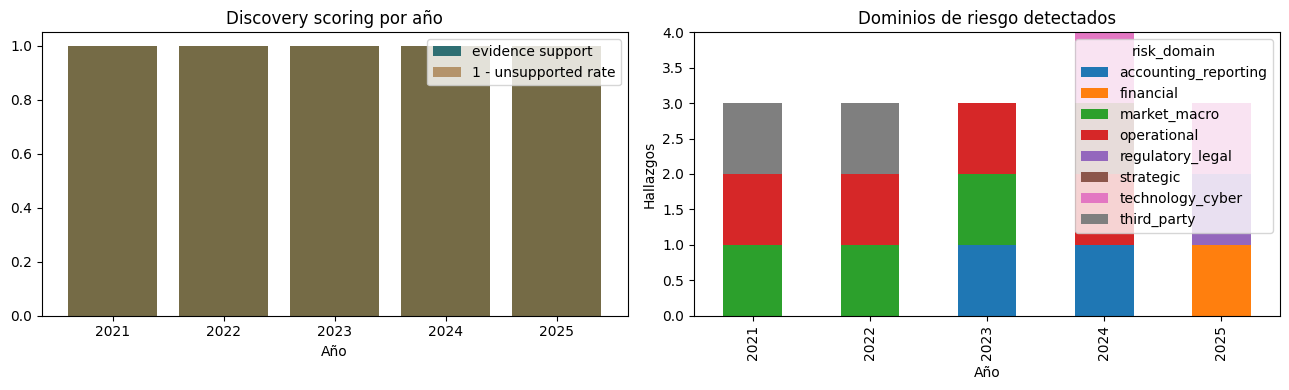

In [9]:
if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(summary_df['year'].astype(str), summary_df['evidence_support_rate'], label='evidence support', color='#2f6f73')
    axes[0].bar(summary_df['year'].astype(str), 1 - summary_df['unsupported_claim_rate'], label='1 - unsupported rate', alpha=0.65, color='#9b6a2f')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title('Discovery scoring por año')
    axes[0].set_xlabel('Año')
    axes[0].legend()

    domain_counts = model_risks_df.groupby(['year', 'risk_domain']).size().unstack(fill_value=0) if not model_risks_df.empty else pd.DataFrame()
    if not domain_counts.empty:
        domain_counts.plot(kind='bar', stacked=True, ax=axes[1])
        axes[1].set_title('Dominios de riesgo detectados')
        axes[1].set_xlabel('Año')
        axes[1].set_ylabel('Hallazgos')
    else:
        axes[1].text(0.5, 0.5, 'Sin hallazgos del modelo', ha='center', va='center')
        axes[1].set_axis_off()
    plt.tight_layout()
else:
    display(Markdown('No hay resultados de modelo para graficar.'))

## Lectura año a año

Esta tabla no forma parte del scoring del caso anual. Sirve para estudiar después si un tema aparece, desaparece o gana peso a lo largo de los años.

In [10]:
if not model_risks_df.empty:
    year_domain = model_risks_df.groupby(['year', 'risk_domain']).size().unstack(fill_value=0)
    display(year_domain)
else:
    display(Markdown('Sin resultados del modelo: ejecuta la celda de DeepSeek cuando haya credenciales disponibles.'))

risk_domain,accounting_reporting,financial,market_macro,operational,regulatory_legal,strategic,technology_cyber,third_party
year,,,,,,,,
2021,0,0,1,1,0,0,0,1
2022,0,0,1,1,0,0,0,1
2023,1,0,1,1,0,0,0,0
2024,1,0,0,1,0,1,1,0
2025,0,1,0,0,1,0,1,0


## Caveat de revisión

En discovery mode no hay `expected_hidden_risks` manuales. Esto hace la eval agnóstica de compañía y sector: el modelo descubre el `sector_specific_topic` y el scorer comprueba schema, citas exactas y soporte en el filing. Si más adelante quieres un benchmark gold, puedes añadir `expected_hidden_risks` a algunos casos y el mismo runner cambiará automáticamente a benchmark mode.